In [1]:
# ─────────────────────────────────────────────────────────────────────
# 1. IMPORTS
# ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
 
# Configurações visuais
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

In [2]:
# ─────────────────────────────────────────────────────────────────────
# 2. DADOS
# ─────────────────────────────────────────────────────────────────────
# Exemplo didático: dados fictícios de clientes
np.random.seed(42)
n = 300
 
df = pd.DataFrame({
    "renda_mensal":        np.concatenate([
        np.random.normal(3000,  800, 100),
        np.random.normal(8000, 1500, 100),
        np.random.normal(15000, 3000, 100),
    ]),
    "gasto_mensal":        np.concatenate([
        np.random.normal(2000,  500, 100),
        np.random.normal(4000, 1000, 100),
        np.random.normal(9000, 2000, 100),
    ]),
    "frequencia_compras":  np.concatenate([
        np.random.normal(2,  1, 100),
        np.random.normal(6,  2, 100),
        np.random.normal(12, 3, 100),
    ]),
    "ticket_medio":        np.concatenate([
        np.random.normal(80,  20, 100),
        np.random.normal(200, 50, 100),
        np.random.normal(500, 100, 100),
    ]),
})
 
# ── Selecione apenas colunas numéricas (segurança extra) ─────────────
colunas_quantitativas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f" Variáveis selecionadas: {colunas_quantitativas}")
print(f" Shape dos dados: {df.shape}\n")

 Variáveis selecionadas: ['renda_mensal', 'gasto_mensal', 'frequencia_compras', 'ticket_medio']
 Shape dos dados: (300, 4)



In [3]:
df.head()

,renda_mensal,gasto_mensal,frequencia_compras,ticket_medio
0,3397.371322,1585.502495,2.756989,87.373466
1,2889.388559,1719.909480,1.077835,72.133224
2,3518.150830,2373.646803,2.869606,80.574896
3,4218.423885,2305.185133,3.355638,105.569037
4,2812.677300,1989.549203,2.413435,83.821981


In [4]:
# ─────────────────────────────────────────────────────────────────────
# 3. PRÉ-PROCESSAMENTO — Padronização (StandardScaler)
# ─────────────────────────────────────────────────────────────────────
# POR QUE PADRONIZAR?
#   K-Means usa distância euclidiana. Sem padronizar, variáveis com
#   escalas maiores (ex: renda em milhares) dominam variáveis menores
#   (ex: frequência de 1 a 15). A padronização coloca tudo na mesma
#   escala: média = 0, desvio padrão = 1.
 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[colunas_quantitativas])

In [5]:
# ┌──────────────────────────────────────────────────────────────────┐
# │                 CONCEITO 1: INÉRCIA (WCSS)                      │
# ├──────────────────────────────────────────────────────────────────┤
# │                                                                  │
# │  O que é?                                                        │
# │    Inércia = Within-Cluster Sum of Squares (WCSS).               │
# │    É a soma das distâncias euclidianas ao quadrado de cada        │
# │    ponto até o centróide do seu cluster.                          │
# │                                                                  │
# │  Fórmula intuitiva:                                              │
# │    Inércia = Σ (para cada cluster) Σ (para cada ponto no         │
# │              cluster) ||ponto - centróide||²                      │
# │                                                                  │
# │  Analogia do dia a dia:                                          │
# │    Imagine que cada cluster é uma escola e cada ponto é um        │
# │    aluno. A inércia mede a distância TOTAL que todos os alunos   │
# │    percorrem até a sua escola. Quanto menor a inércia, mais      │
# │    perto cada aluno mora da sua escola → clusters mais compactos.│
# │                                                                  │
# │  Por que não usar só a inércia?                                  │
# │    A inércia SEMPRE diminui quando K aumenta. Com K = N (cada    │
# │    ponto é um cluster), a inércia é zero — mas isso não serve    │
# │    pra nada. O truque é achar o "cotovelo": o ponto onde         │
# │    adicionar mais clusters para de trazer ganho significativo.    │
# │                                                                  │
# │  Limitação:                                                      │
# │    O cotovelo nem sempre é claro. Em dados reais, a curva pode   │
# │    ser suave sem um ponto de inflexão óbvio. Por isso usamos     │
# │    uma segunda métrica para confirmar.                            │
# │                                                                  │
# └──────────────────────────────────────────────────────────────────┘
#
# ┌──────────────────────────────────────────────────────────────────┐
# │           CONCEITO 2: SILHOUETTE SCORE (Rousseeuw, 1987)        │
# ├──────────────────────────────────────────────────────────────────┤
# │                                                                  │
# │  O que é?                                                        │
# │    Mede simultaneamente duas coisas para CADA ponto:              │
# │    • a(i) = distância média do ponto i até os OUTROS pontos      │
# │            do MESMO cluster (coesão interna)                      │
# │    • b(i) = distância média do ponto i até os pontos do          │
# │            cluster VIZINHO MAIS PRÓXIMO (separação externa)       │
# │                                                                  │
# │  Fórmula:                                                        │
# │              b(i) - a(i)                                          │
# │    s(i) = ─────────────────                                       │
# │           max( a(i), b(i) )                                       │
# │                                                                  │
# │  Interpretação do valor s(i) de cada ponto:                      │
# │                                                                  │
# │    +1.0  ██████████  Perfeito: ponto bem dentro do seu cluster   │
# │    +0.7  ███████     Bom: ponto bem alocado                      │
# │    +0.5  █████       Aceitável: no limite entre clusters         │
# │     0.0  ▓           Ambíguo: entre dois clusters                │
# │    -1.0  ░░░░░░░░░░  Péssimo: provavelmente no cluster errado   │
# │                                                                  │
# │  Analogia do dia a dia:                                          │
# │    Pense num aluno numa escola. O Silhouette pergunta:            │
# │    "Esse aluno se parece mais com os colegas da SUA escola (a)   │
# │     ou com os alunos da escola vizinha mais próxima (b)?"         │
# │    Se b >> a → aluno está na escola certa → score alto (+1)      │
# │    Se a >> b → aluno deveria trocar de escola → score baixo (-1) │
# │                                                                  │
# │  Score global:                                                    │
# │    O Silhouette Score do modelo é a MÉDIA de s(i) de todos os    │
# │    pontos. Regra prática (Kaufman & Rousseeuw, 1990):            │
# │      • > 0.70  →  estrutura forte                                │
# │      • 0.50–0.70 → estrutura razoável                            │
# │      • 0.25–0.50 → estrutura fraca, pode ser artificial          │
# │      • < 0.25  →  sem estrutura significativa                    │
# │                                                                  │
# │  Por que usar os dois juntos?                                    │
# │    Inércia mostra a TENDÊNCIA (onde a curva "quebra").            │
# │    Silhouette dá um NÚMERO OBJETIVO para comparar K's.           │
# │    Quando os dois concordam, você tem confiança na escolha.      │
# │    Quando discordam, prefira o Silhouette + bom senso de negócio.│
# │                                                                  │
# └──────────────────────────────────────────────────────────────────┘

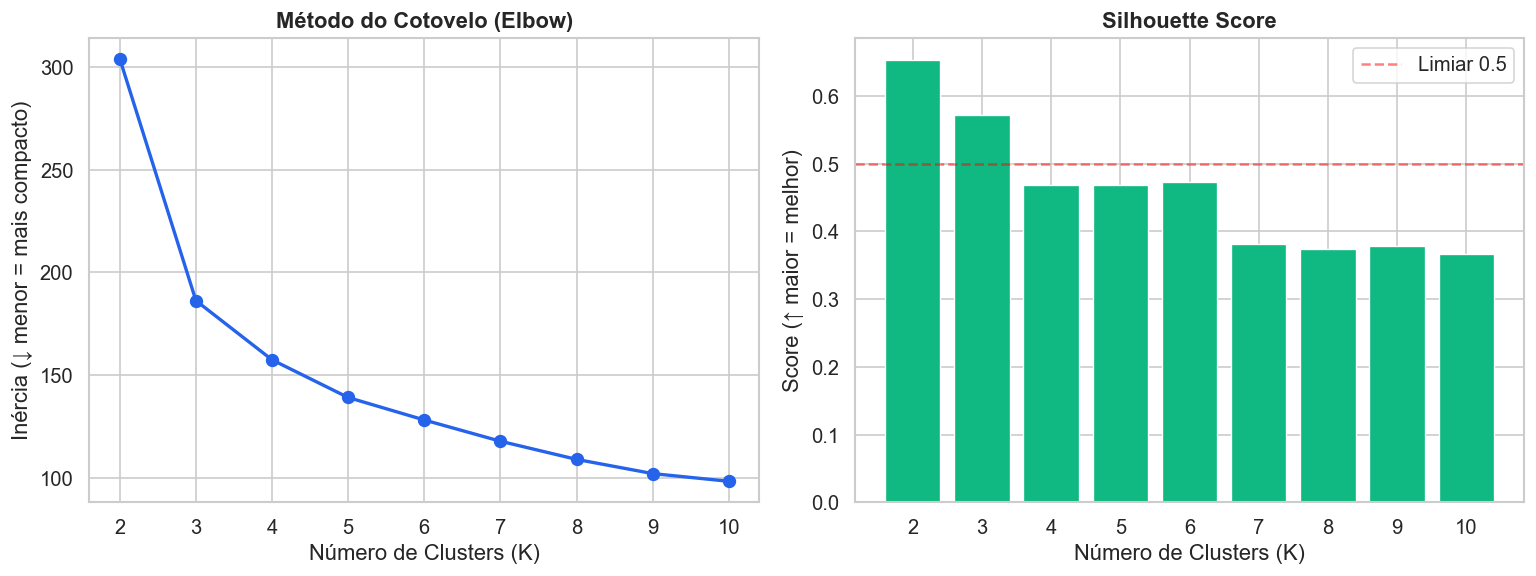

In [6]:
# ─────────────────────────────────────────────────────────────────────
# 4. ESCOLHA DO NÚMERO IDEAL DE CLUSTERS (K)
# ─────────────────────────────────────────────────────────────────────
# Duas métricas complementares:
#   • Inércia (Elbow): soma das distâncias ao centróide → menor = melhor
#   • Silhouette Score: coesão interna vs separação → maior = melhor
#     Varia de -1 (péssimo) a +1 (perfeito). Acima de 0.5 já é bom.
 
K_MIN, K_MAX = 2, 10
intervalo_k = range(K_MIN, K_MAX + 1)
 
inercias = []
silhouettes = []
 
for k in intervalo_k:
    modelo = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = modelo.fit_predict(X_scaled)
    inercias.append(modelo.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
 
# ── Gráfico: Elbow + Silhouette lado a lado ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
 
# Elbow
ax1.plot(intervalo_k, inercias, "o-", color="#2563EB", linewidth=2, markersize=7)
ax1.set_title("Método do Cotovelo (Elbow)", fontweight="bold")
ax1.set_xlabel("Número de Clusters (K)")
ax1.set_ylabel("Inércia (↓ menor = mais compacto)")
ax1.set_xticks(list(intervalo_k))
 
# Silhouette
ax2.bar(intervalo_k, silhouettes, color="#10B981", edgecolor="white", linewidth=0.8)
ax2.set_title("Silhouette Score", fontweight="bold")
ax2.set_xlabel("Número de Clusters (K)")
ax2.set_ylabel("Score (↑ maior = melhor)")
ax2.set_xticks(list(intervalo_k))
ax2.axhline(y=0.5, color="red", linestyle="--", alpha=0.5, label="Limiar 0.5")
ax2.legend()
 
plt.tight_layout()
plt.show()

In [7]:
k_otimo = 3

In [8]:
# ─────────────────────────────────────────────────────────────────────
# 5. MODELO FINAL — K-Means com K ótimo
# ─────────────────────────────────────────────────────────────────────
# K-MEANS++ (Arthur & Vassilvitskii, 2007):
#   Inicializa os centróides de forma espalhada, evitando convergência
#   para mínimos locais ruins. É o padrão do scikit-learn.
 
modelo_final = KMeans(
    n_clusters=k_otimo,
    init="k-means++",   # inicialização inteligente
    n_init=30,           # roda 30 vezes, pega o melhor resultado
    max_iter=300,        # iterações máximas por rodada
    random_state=42,     # reprodutibilidade
)
 
df["cluster"] = modelo_final.fit_predict(X_scaled)
 
print(f"✔ Distribuição dos clusters:")
print(df["cluster"].value_counts().sort_index().to_string())
print()

✔ Distribuição dos clusters:
cluster
0    100
1    100
2    100



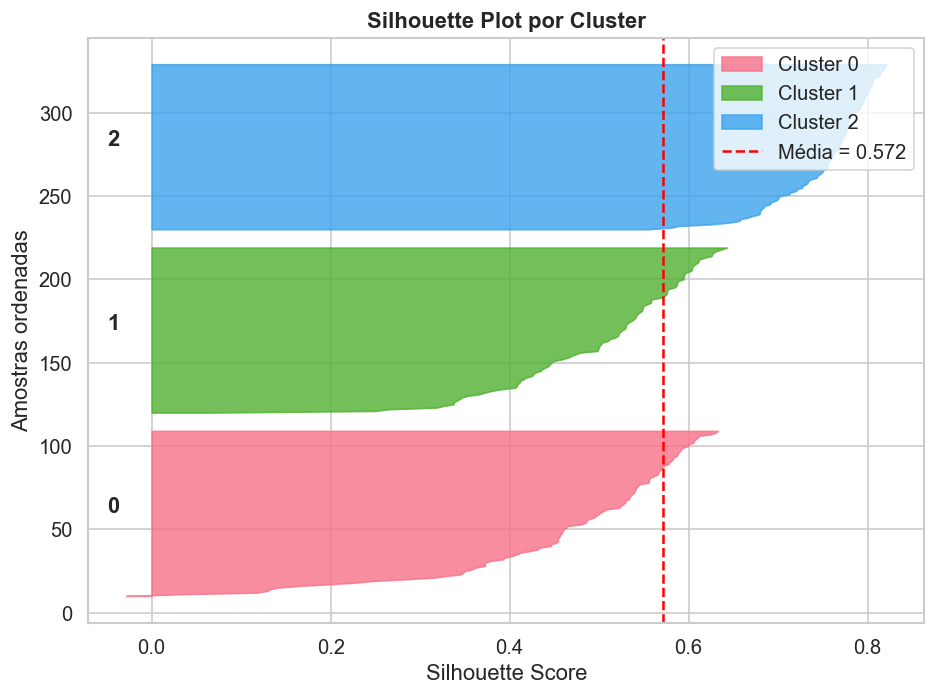

In [9]:
# ─────────────────────────────────────────────────────────────────────
# 6. VISUALIZAÇÃO — Silhouette Plot por cluster
# ─────────────────────────────────────────────────────────────────────
# Este gráfico mostra a "qualidade" de cada ponto dentro do seu cluster.
# Barras grandes e uniformes = cluster bem definido.
# Barras negativas = pontos que provavelmente estão no cluster errado.
 
sil_vals = silhouette_samples(X_scaled, df["cluster"])
sil_medio = silhouette_score(X_scaled, df["cluster"])
 
fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
cores = sns.color_palette("husl", k_otimo)
 
for i in range(k_otimo):
    vals_cluster = np.sort(sil_vals[df["cluster"] == i])
    tamanho = len(vals_cluster)
    y_upper = y_lower + tamanho
 
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_cluster,
                      alpha=0.8, color=cores[i], label=f"Cluster {i}")
    ax.text(-0.05, y_lower + 0.5 * tamanho, str(i), fontweight="bold")
    y_lower = y_upper + 10
 
ax.axvline(x=sil_medio, color="red", linestyle="--",
           label=f"Média = {sil_medio:.3f}")
ax.set_title("Silhouette Plot por Cluster", fontweight="bold")
ax.set_xlabel("Silhouette Score")
ax.set_ylabel("Amostras ordenadas")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────────────────────
# 7. PERFILAMENTO DOS CLUSTERS (a parte mais importante para negócio!)
# ─────────────────────────────────────────────────────────────────────
# Esta tabela responde: "O que define cada grupo?"
# Mostramos a MÉDIA de cada variável por cluster + o tamanho do grupo.
 
perfil = df.groupby("cluster")[colunas_quantitativas].agg(["mean", "median"])
perfil.columns = [f"{col}_{stat}" for col, stat in perfil.columns]
 
# Adiciona contagem e percentual
contagem = df["cluster"].value_counts().sort_index()
perfil["n_clientes"] = contagem.values
perfil["percentual"] = (contagem.values / len(df) * 100).round(1)
 
perfil

,renda_mensal_mean,renda_mensal_median,gasto_mensal_mean,gasto_mensal_median,frequencia_compras_mean,frequencia_compras_median,ticket_medio_mean,ticket_medio_median,n_clientes,percentual
cluster,,,,,,,,,,
0,8033.456881,8126.160755,3943.995529,3924.100432,5.987679,6.143984,208.008721,209.88776,100,33.3
1,15194.688759,15293.087227,8769.388803,8778.242966,12.685947,12.469749,510.709162,519.04966,100,33.3
2,2916.922786,2898.434967,2053.420060,2025.078683,2.024094,1.956476,80.557076,81.74541,100,33.3


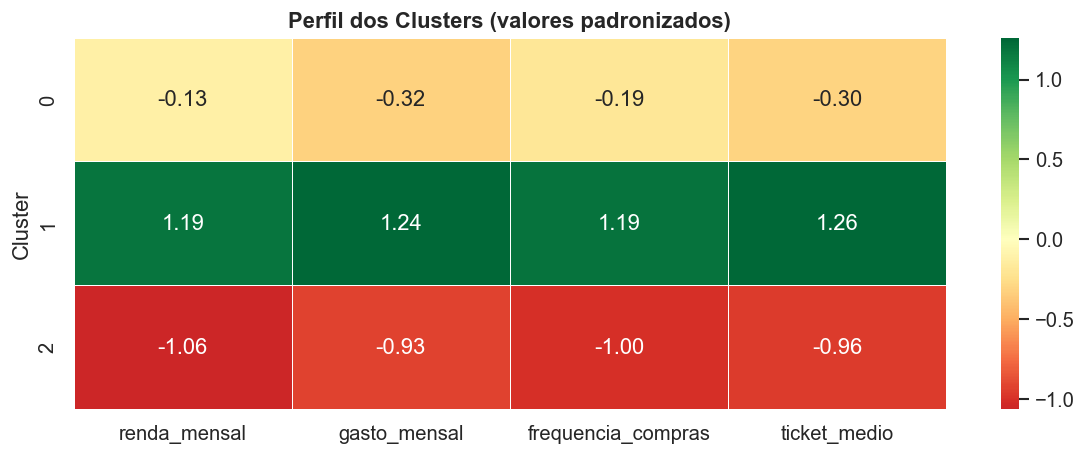

In [11]:
# ─────────────────────────────────────────────────────────────────────
# 8. HEATMAP DE PERFIL (visualização rápida das diferenças)
# ─────────────────────────────────────────────────────────────────────
# Usa os dados padronizados para comparar os clusters numa escala justa.
 
medias_padronizadas = pd.DataFrame(
    X_scaled, columns=colunas_quantitativas
).assign(cluster=df["cluster"].values).groupby("cluster").mean()
 
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    medias_padronizadas,
    annot=True, fmt=".2f", cmap="RdYlGn", center=0,
    linewidths=0.5, ax=ax,
)
ax.set_title("Perfil dos Clusters (valores padronizados)", fontweight="bold")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()